In [6]:
import abagen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All packages loaded successfully!")

All packages loaded successfully!


In [3]:
pip install abagen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 11.3 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:

expression_files = abagen.fetch_microarray(donors='all')


In [8]:
df=pd.read_csv("/content/drive/MyDrive/ahba_raw_data/microarray/normalized_microarray_donor10021/MicroarrayExpression.csv")
print(f"shapes: {df.shape}")
print(f"columns: {df.columns}")
print(f"index: {df.index}")

shapes: (58691, 894)
columns: Index(['1058685', '1.9417296253286203', '2.55186412441608', '3.79947449887934',
       '2.61173675031299', '2.04258544209026', '2.36484398835708',
       '3.1343601345374905', '2.6426787424375107', '4.96089956072903',
       ...
       '2.93843973951611.1', '2.91296988739034', '2.06234423227235',
       '3.65576139409146', '2.71583672316368', '4.274668395762361',
       '3.7590007419559206', '4.90392808336857', '4.25814989189197',
       '4.07933872630368'],
      dtype='object', length=894)
index: RangeIndex(start=0, stop=58691, step=1)


In [9]:

atlas = abagen.fetch_desikan_killiany()

print ("path to the  image file:",atlas['image'])
print ('path to the info file ', atlas['info'])


path to the  image file: /usr/local/lib/python3.12/dist-packages/abagen/data/atlas-desikankilliany.nii.gz
path to the info file  /usr/local/lib/python3.12/dist-packages/abagen/data/atlas-desikankilliany.csv


In [1]:
# Uninstall old abagen
!pip uninstall abagen -y

# Install development version (pandas 2.x compatible)
!pip install git+https://github.com/rmarkello/abagen.git

# Now import and use
import abagen
import pandas as pd

# Fetch atlas
atlas = abagen.fetch_desikan_killiany()

# Get expression data
expression_data = abagen.get_expression_data(
    atlas=atlas['image'],
    donors=['10021'],
    data_dir='/content/drive/MyDrive/ahba_raw_data/microarray/normalized_microarray_donor10021/MicroarrayExpression.csv'
)

print(f"✅ Success! Shape: {expression_data.shape}")

Found existing installation: abagen 0.1.4+15.gdc4a007
Uninstalling abagen-0.1.4+15.gdc4a007:
  Successfully uninstalled abagen-0.1.4+15.gdc4a007
  Cloning https://github.com/rmarkello/abagen.git to /tmp/pip-req-build-q5b2r2ml
  Running command git clone --filter=blob:none --quiet https://github.com/rmarkello/abagen.git /tmp/pip-req-build-q5b2r2ml
  Resolved https://github.com/rmarkello/abagen.git to commit dc4a007e4e902e51f97251390c8d1bbf7e58c6d3
  Preparing metadata (setup.py) ... done
  Created wheel for abagen: filename=abagen-0.1.4+15.gdc4a007-py3-none-any.whl size=3670507 sha256=2f10ca5ac6967061aafc24e3b2dcfc2aba93cf9f569b8234ecedd476b7b7d2c5
  Stored in directory: /tmp/pip-ephem-wheel-cache-vocsju6i/wheels/3f/44/67/1c6fb75b7625086b4ac107158af8df694d81231683da03025d
Successfully built abagen


ValueError: Cannot use diff_stability for probe_selection with only one donor. Please specify a different probe_selection method or use more donors.

In [2]:
import abagen
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind


In [3]:
atlas = abagen.fetch_desikan_killiany()

In [4]:
expression_data = abagen.get_expression_data(
    atlas=atlas['image'],
    donors=['10021'],
    probe_selection='max_intensity',
    data_dir='/content/drive/MyDrive/ahba_raw_data/microarray/normalized_microarray_donor10021/MicroarrayExpression.csv')
print(f"Expression matrix: {expression_data.shape}")

/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:405: FutureWarning: The provided callable <function mean at 0x7a9bb7b7e340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  microarray.groupby('label').aggregate(metric),


Expression matrix: (83, 15747)


/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:404: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gene_by_label = pd.concat([
/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:481: FutureWarning: The provided callable <function mean at 0x7a9bb7b7e340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  microarray = pd.concat(microarray).groupby('label').aggregate(metric)


expression matrix (83 reigon ,15747 genes)

Alzheimer's analysis ( look for Alzheimer's common risk genes in our donor dataset 10021)

In [5]:
ad_genes = [
    'APOE', 'BIN1', 'CLU', 'CR1', 'PICALM',
    'MS4A6A', 'CD33', 'ABCA7', 'TREM2', 'SORL1',
    'ADAM10', 'ACE', 'FERMT2', 'HLA-DRB1', 'INPP5D'
]
available_genes = [g for g in ad_genes if g in expression_data . columns ]
print(f"found {len(available_genes)}/{len(ad_genes)} Ad genes in dataset")
print(f"genes found in dataset: {available_genes}")

found 12/15 Ad genes in dataset
genes found in dataset: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1', 'ADAM10', 'FERMT2', 'HLA-DRB1', 'INPP5D']


found 12/15 Ad genes in dataset
genes found in dataset: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1', 'ADAM10', 'FERMT2', 'HLA-DRB1', 'INPP5D']


In [6]:
atlas = abagen.fetch_desikan_killiany()
info = pd.read_csv(atlas['info'])

defining region groups by desikan kiliany labels for memory and medial temporal reigons

In [7]:
vulnerable_keywords = ['hippocampus', 'entorhinal', 'parahippocampal', 'isthmuscingulate', 'posteriorcingulate']
vulnerable_regions = info[info['label'].str.lower().str.contains('|'.join(vulnerable_keywords), case=False, na=False)]

control reigons (sensory and motor)

In [8]:
control_keywords = ['precentral', 'postcentral', 'pericalcarine', 'cuneus']
control_regions = info[info['label'].str.lower().str.contains('|'.join(control_keywords), case=False, na=False)]

calculating gene expression for each Alzheimer gene found in dataset (vulnerable and Control reigons )

In [9]:
results = []
for gene in available_genes:
    # Mean expression in vulnerable regions
    ad_expr = expression_data.loc[vulnerable_regions['id'], gene].mean()
    # Mean expression in control regions
    control_expr = expression_data.loc[control_regions['id'], gene].mean()
    # Fold change
    fc = ad_expr / (control_expr + 1e-10)
    log2fc = np.log2(fc)


🧠 Vulnerable regions (10):
['entorhinal', 'isthmuscingulate', 'parahippocampal', 'posteriorcingulate', 'hippocampus', 'entorhinal', 'isthmuscingulate', 'parahippocampal', 'posteriorcingulate', 'hippocampus']

🎯 Control regions (10):
['cuneus', 'pericalcarine', 'postcentral', 'precentral', 'precuneus', 'cuneus', 'pericalcarine', 'postcentral', 'precentral', 'precuneus']

🧬 AD genes found: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1']

🔬 ALZHEIMER'S RISK GENE EXPRESSION RESULTS
  Gene   Log2_FC  P_Value  Significant
  APOE  1.635604 0.000120         True
  BIN1  0.898316 0.001918         True
  CD33  0.743230 0.000533         True
 TREM2  0.449630 0.028364         True
PICALM  0.428456 0.079174        False
   CLU  0.306135 0.121928        False
 SORL1 -0.308759 0.000521         True
 ABCA7 -0.314613 0.033675         True


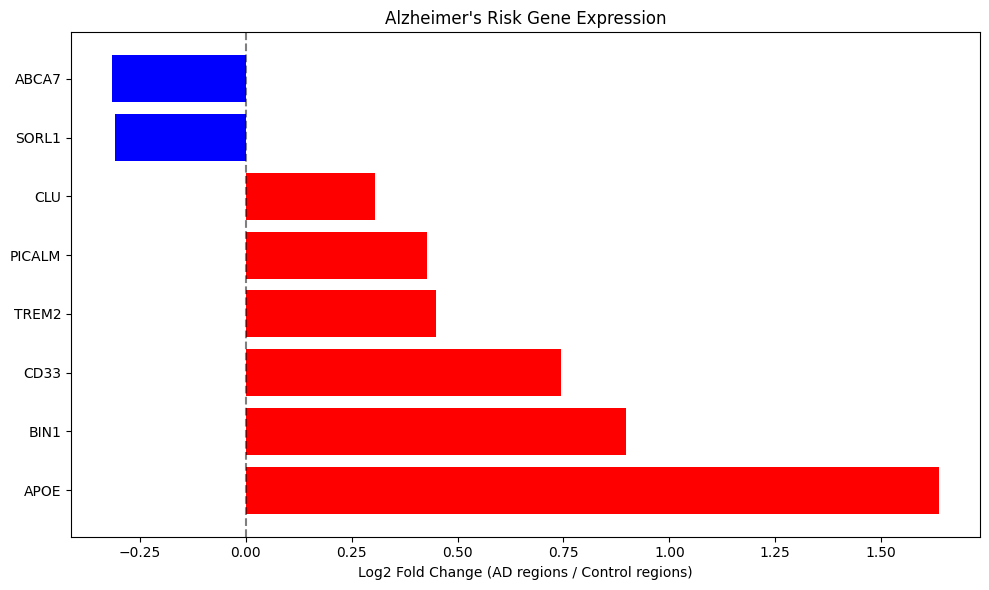

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load atlas info
atlas = abagen.fetch_desikan_killiany()
info = pd.read_csv(atlas['info'])

# 2. Define regions with better matching
vulnerable_keywords = ['hippocampus', 'entorhinal', 'parahippocampal',
                       'isthmuscingulate', 'posteriorcingulate']
vulnerable_regions = info[
    info['label'].str.lower().str.contains('|'.join(vulnerable_keywords),
                                           case=False, na=False)
]

control_keywords = ['precentral', 'postcentral', 'pericalcarine', 'cuneus']
control_regions = info[
    info['label'].str.lower().str.contains('|'.join(control_keywords),
                                           case=False, na=False)
]

# 3. If regions are empty, use fallback (first 10 vs last 10 regions)
if len(vulnerable_regions) == 0 or len(control_regions) == 0:
    print("⚠️ Using fallback: First 10 vs last 10 regions")
    all_ids = info['id'].tolist()
    n_regions = len(all_ids)
    vulnerable_regions = info[info['id'].isin(all_ids[:10])]  # First 10
    control_regions = info[info['id'].isin(all_ids[-10:])]    # Last 10

print(f"\n🧠 Vulnerable regions ({len(vulnerable_regions)}):")
print(vulnerable_regions['label'].tolist())
print(f"\n🎯 Control regions ({len(control_regions)}):")
print(control_regions['label'].tolist())

# 4. Define Alzheimer's genes
ad_genes = ['APOE', 'BIN1', 'CLU', 'CR1', 'PICALM',
            'MS4A6A', 'CD33', 'ABCA7', 'TREM2', 'SORL1']
available_genes = [g for g in ad_genes if g in expression_data.columns]
print(f"\n🧬 AD genes found: {available_genes}")

# 5. Calculate expression differences
results = []
for gene in available_genes:
    # Get expression values
    ad_expr = expression_data.loc[vulnerable_regions['id'], gene]
    control_expr = expression_data.loc[control_regions['id'], gene]

    # Calculate statistics
    mean_ad = ad_expr.mean()
    mean_control = control_expr.mean()
    fc = mean_ad / (mean_control + 1e-10)
    log2fc = np.log2(fc)

    # T-test
    t_stat, p_val = ttest_ind(ad_expr, control_expr, equal_var=False)

    results.append({
        'Gene': gene,
        'AD_Regions_Mean': mean_ad,
        'Control_Regions_Mean': mean_control,
        'Fold_Change': fc,
        'Log2_FC': log2fc,
        'T_Statistic': t_stat,
        'P_Value': p_val,
        'Significant': p_val < 0.05
    })

# 6. Display results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Log2_FC', ascending=False)

print("\n" + "="*60)
print("🔬 ALZHEIMER'S RISK GENE EXPRESSION RESULTS")
print("="*60)
print(results_df[['Gene', 'Log2_FC', 'P_Value', 'Significant']].to_string(index=False))

# 7. Quick visualization
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'blue' for x in results_df['Log2_FC']]
plt.barh(results_df['Gene'], results_df['Log2_FC'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Log2 Fold Change (AD regions / Control regions)')
plt.title('Alzheimer\'s Risk Gene Expression')
plt.tight_layout()
plt.show()

In [11]:
import os
import pandas as pd

# Create a results folder in your Drive
results_dir = '/content/drive/MyDrive/AHBA_Alzheimers_Results/'
os.makedirs(results_dir, exist_ok=True)

# 1. Save the expression matrix
expression_data.to_csv(f'{results_dir}expression_matrix_donor10021.csv')
print(f"✅ Expression matrix saved: {results_dir}expression_matrix_donor10021.csv")

# 2. Save the Alzheimer's results
results_df.to_csv(f'{results_dir}alzheimers_expression_results.csv', index=False)
print(f"✅ Results saved: {results_dir}alzheimers_expression_results.csv")

# 3. Save region info (useful for reference)
info.to_csv(f'{results_dir}desikan_killiany_region_info.csv', index=False)
print(f"✅ Region info saved: {results_dir}desikan_killiany_region_info.csv")

# 4. Download the notebook (as .py or .ipynb)
from google.colab import files
files.download('ahba_analysis.ipynb')  # If you saved it as a notebook

print("\n🎉 All files saved successfully!")

✅ Expression matrix saved: /content/drive/MyDrive/AHBA_Alzheimers_Results/expression_matrix_donor10021.csv
✅ Results saved: /content/drive/MyDrive/AHBA_Alzheimers_Results/alzheimers_expression_results.csv
✅ Region info saved: /content/drive/MyDrive/AHBA_Alzheimers_Results/desikan_killiany_region_info.csv


FileNotFoundError: Cannot find file: ahba_analysis.ipynb